In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv(r"titanic (1).csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

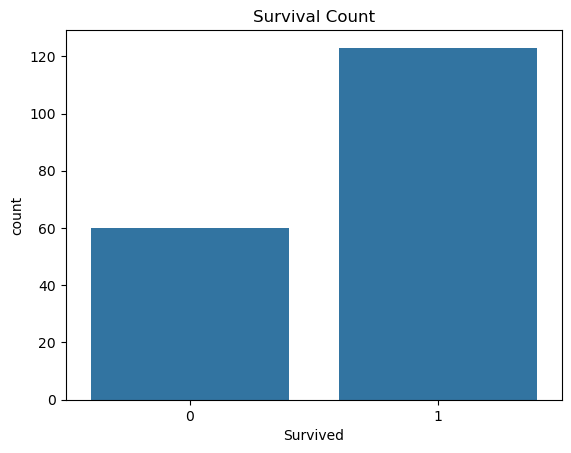

In [11]:
# Countplot for target (if 'Survived' exists)
if 'Survived' in df.columns:
    sns.countplot(data=df, x='Survived')
    plt.title("Survival Count")
    plt.show()

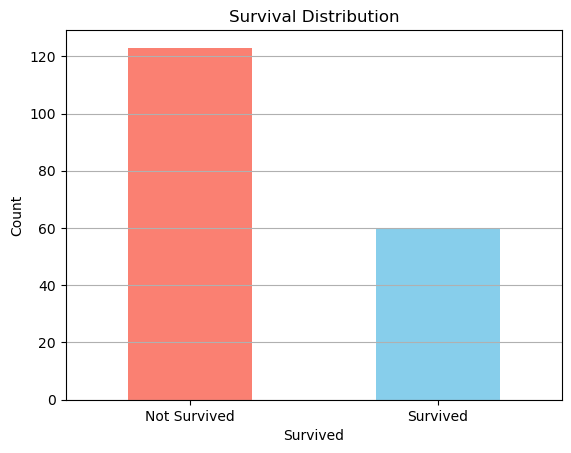

In [12]:
df['Survived'].value_counts().plot(kind='bar', color=['salmon', 'skyblue'])
plt.xticks([0, 1], ['Not Survived', 'Survived'], rotation=0)
plt.ylabel('Count')
plt.title('Survival Distribution')
plt.grid(axis='y')
plt.show()

In [13]:
# Convert categorical → numeric using Label Encoding (SEX)
label_enc = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = label_enc.fit_transform(df[col])

In [14]:
#here we got a highly imbalance data

In [15]:
# Check class distribution
df['Survived'].value_counts()
df['Survived'].value_counts(normalize=True) * 100


Survived
1    67.213115
0    32.786885
Name: proportion, dtype: float64

In [24]:
# Common Sampling Techniques

In [25]:
# Using SMOTE for class imbalance

In [26]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [33]:
# Define features and target
X = df[['Age', 'Pclass', 'Sex']]
y = df['Survived']

In [34]:
from collections import Counter

In [40]:
# Split into train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print("After SMOTE:", Counter(y_res))

After SMOTE: Counter({1: 123, 0: 123})


C:\Users\anant\AppData\Local\Temp\ipykernel_7428\2877271487.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(before.keys()), y=list(before.values()), ax=ax[0], palette='pastel')
C:\Users\anant\AppData\Local\Temp\ipykernel_7428\2877271487.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(after.keys()), y=list(after.values()), ax=ax[1], palette='pastel')


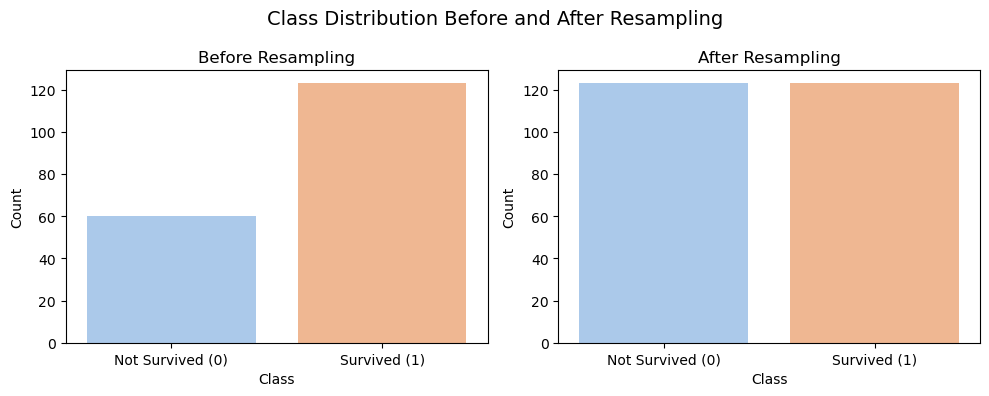

In [41]:
# Count the class distribution
before = Counter(y)
after = Counter(y_res)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Before resampling
sns.barplot(x=list(before.keys()), y=list(before.values()), ax=ax[0], palette='pastel')
ax[0].set_title('Before Resampling')
ax[0].set_xlabel('Class')
ax[0].set_ylabel('Count')
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['Not Survived (0)', 'Survived (1)'])

# After resampling
sns.barplot(x=list(after.keys()), y=list(after.values()), ax=ax[1], palette='pastel')
ax[1].set_title('After Resampling')
ax[1].set_xlabel('Class')
ax[1].set_ylabel('Count')
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['Not Survived (0)', 'Survived (1)'])

plt.suptitle('Class Distribution Before and After Resampling', fontsize=14)
plt.tight_layout()
plt.show()


In [42]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train Naive Bayes on SMOTE data
nb = GaussianNB()
nb.fit(X_res, y_res)

# Predict on test set (unseen data)
y_pred = nb.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7837837837837838

Confusion Matrix:
 [[11  1]
 [ 7 18]]

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.92      0.73        12
           1       0.95      0.72      0.82        25

    accuracy                           0.78        37
   macro avg       0.78      0.82      0.78        37
weighted avg       0.84      0.78      0.79        37



In [ ]:
#after applying smote the naive bias provide an accuracy of 0.78 which is similar to naive bias before resampling

In [43]:
# Now we can apply rendom over sampling

In [44]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter


In [45]:
# Split into train and test sets (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Before Oversampling:", Counter(y_train))


Before Oversampling: Counter({1: 98, 0: 48})


In [46]:
# Apply random oversampling only on training data
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)

print("After Random Oversampling:", Counter(y_res))


After Random Oversampling: Counter({0: 98, 1: 98})


In [47]:
# Train Naive Bayes model on oversampled data
nb = GaussianNB()
nb.fit(X_res, y_res)

# Predict on test set
y_pred = nb.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7837837837837838

Confusion Matrix:
 [[11  1]
 [ 7 18]]

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.92      0.73        12
           1       0.95      0.72      0.82        25

    accuracy                           0.78        37
   macro avg       0.78      0.82      0.78        37
weighted avg       0.84      0.78      0.79        37



In [55]:
#applying decision tree after sampling

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_res, y_res)

# Predict and evaluate
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))



Decision Tree Accuracy: 0.7837837837837838
              precision    recall  f1-score   support

           0       0.64      0.75      0.69        12
           1       0.87      0.80      0.83        25

    accuracy                           0.78        37
   macro avg       0.76      0.78      0.76        37
weighted avg       0.80      0.78      0.79        37



In [57]:
#applying decision tree also not worked well
